In [3]:
import torch
import sys
sys.path.append('../')
import time
from ttpi import TTPI 
from dynamic_systems import HardMove
torch.set_default_dtype(torch.float64)
%load_ext autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device 

device(type='cpu')

In [5]:
dt=0.01
dyn_system =  HardMove(dt=dt,w_goal=1e3, w_action=1e4, device=device)


In [6]:
def forward_model(state,action):
    next_state = dyn_system.forward_simulate(state,action)
    return next_state


def reward(state,action):
    rewards = dyn_system.reward_state_action(state, action)
    return rewards

In [7]:
L = 1.
position_max=L
position_min= -1*L

n_state = 50
n_actuator = 12
n_action = 100

velocity_max = 0.25*position_max
velocity_min = 0*velocity_max
acc_max = 1*velocity_max
acc_min = -1*acc_max

domain_acc0 = torch.linspace(acc_min,acc_max,n_action).to(device)

domain_switch0 = torch.arange(2).to(device)

# dim=4
state_min = torch.tensor([position_min, position_min, velocity_min, velocity_min]).to(device) #[x, y, x_dot, y_dot]
state_max = torch.tensor([position_max, position_max, velocity_max, velocity_max]).to(device)


domain_state = [torch.linspace(state_min[i],state_max[i],n_state).to(device) for i in range(len(state_max))]  
domain_action = [domain_acc0,domain_switch0]*n_actuator

action_max = acc_max
action_min = -acc_max

In [8]:
len(domain_state)


4

In [9]:
x_obst = []
r_obst = []

In [10]:
n_test = 20
dim_state = len(domain_state)
init_state = torch.empty((n_test,dim_state))
for i in range(dim_state):
    init_state[:,i] = state_min[i] + torch.rand(n_test).clip(0.25,0.75).to(device)*(state_max[i]-state_min[i])
state = init_state.to(device)
state[:, 2:4] = 0* state[:, 2:4]

In [11]:
def callback(ttpi,state=state,file_name='fig', callback_count=0):
    N = 1
    S = torch.empty(N); Mu = torch.empty(N);
    history = []
    T = int(10/dt)
    traj = state[:,:2].clone()[:,None,:]
    cum_reward = torch.tensor([0.]*state.shape[0]).to(device)
    for i in range(T):
        action =  ttpi.policy(state) #lqr_policy(state)#
        r = dyn_system.reward_state_action(state,action)
        cum_reward+=r
        state = dyn_system.forward_simulate(state,action)
        position = state[:,:2]
        traj = torch.concat((traj,position[:,None,:2]),dim=1)
    
    from matplotlib import pyplot as plt
    print("Cumulative reward: ", cum_reward.mean())
    print("Avg: ", torch.mean(cum_reward))
    from plot_utils import plot_point_mass
    plt=plot_point_mass(traj.to('cpu'),x_target=torch.tensor([0,0]).to('cpu'), x_obst=[x.to('cpu') for x in x_obst], r_obst=r_obst, figsize=5)
    plt.grid()
    plt.show()
    return r.mean().to("cpu"),cum_reward.mean().to("cpu")


In [12]:
ttpi = TTPI(domain_state=domain_state,
                domain_action=domain_action, 
                reward=reward,
                normalize_reward=True,
                forward_model=forward_model, 
                gamma=0.99, 
                rmax_v=100, rmax_a=100, 
                nswp_v=5, nswp_a=10, 
                kickrank_v=10, kickrank_a=10,
                max_batch_v=10**4,max_batch_a=10**5,
                eps_cross_v=1e-3,
                eps_cross_a=1e-3,
                eps_round_v=1e-3, 
                eps_round_a=1e-3, 
                n_samples=50, 
                verbose=True, 
                device=device) # action = 'deterministic_tt', 'stochastic_tt', 'random'

#############################################################################
Learning begins
#############################################################################
Computing reward function in TT format for normalization
cross device is cpu
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
Cross-approximation over a 28D domain containing 2.56e+34 grid points:
iter: 0  | eps: 3.170e-01 | time:   0.0741 | largest rank:   1
iter: 1  | eps: 1.909e-15 | time:   0.5676 | largest rank:  11 <- converged: eps < 0.0001
Did 316174 function evaluations, which took 0.07121s (4.44e+06 evals/s)

Rank of reward:  tensor([1, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])
Initialize policy (q-fcn) by random initialization of value-function....
Cumulative reward:  tensor(-3.411106e+09)
Avg:  

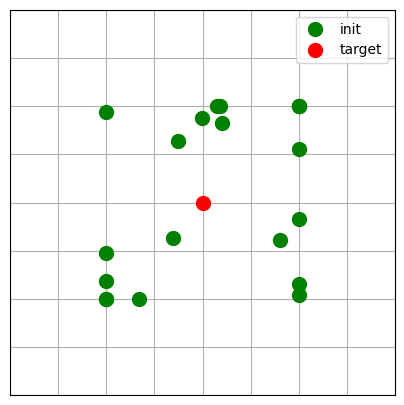

Memory:  0.0 0.0
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Policy Iteration 1/1000
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Number of value updates:  1
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
.....................................................
Computing Advantage Fcn
.....................................................
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
v_min: -0.01, v_mean: -0.00, v_max: -0.00
a_min: -1.00, a_mean: -0.35, a_max: -0.00
p_min: 2.00, p_mean: 2.65, p_max: 3.00
Rank of V-model:  tensor([1, 2, 1, 1, 1])
Rank of A-model:  tensor([1, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])
Ra

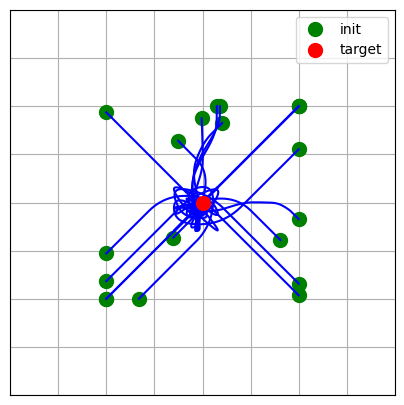

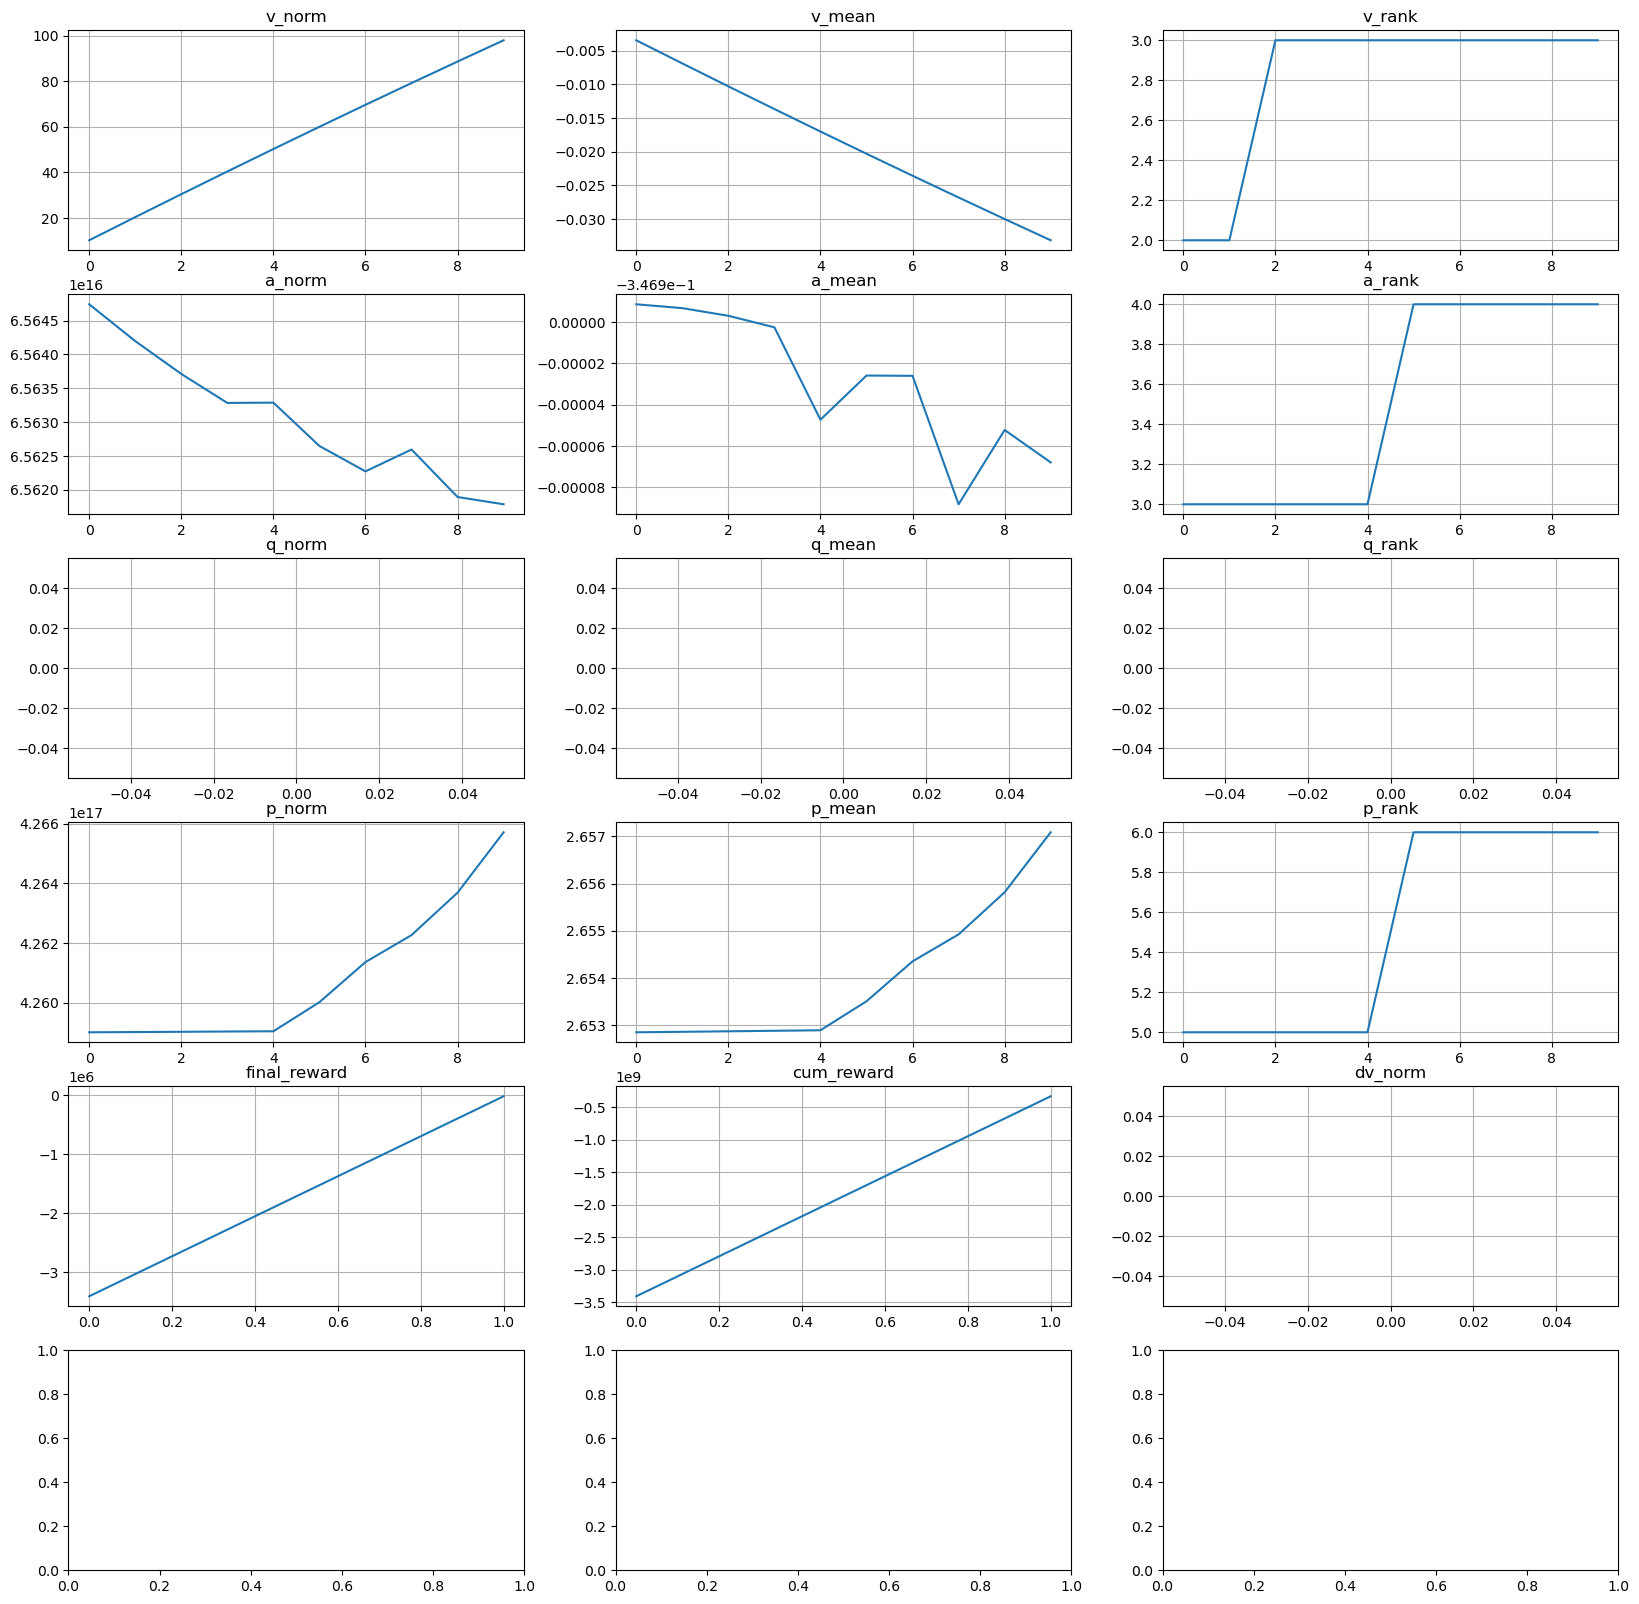

Memory:  0.0 0.0
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Policy Iteration 11/1000
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Number of value updates:  1
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
.....................................................
Computing Advantage Fcn
.....................................................
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
v_min: -0.10, v_mean: -0.04, v_max: -0.00
a_min: -1.00, a_mean: -0.35, a_max: -0.00
p_min: 2.00, p_mean: 2.66, p_max: 3.00
Rank of V-model:  tensor([1, 3, 3, 2, 1])
Rank of A-model:  tensor([1, 3, 3, 3, 3, 4, 3, 4, 3, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])
R

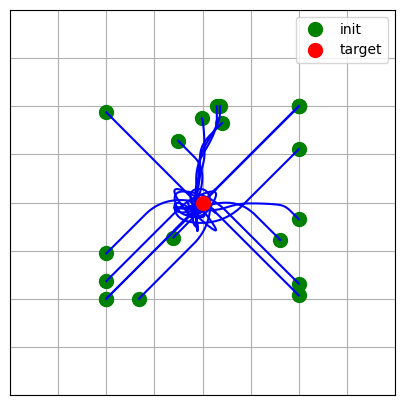

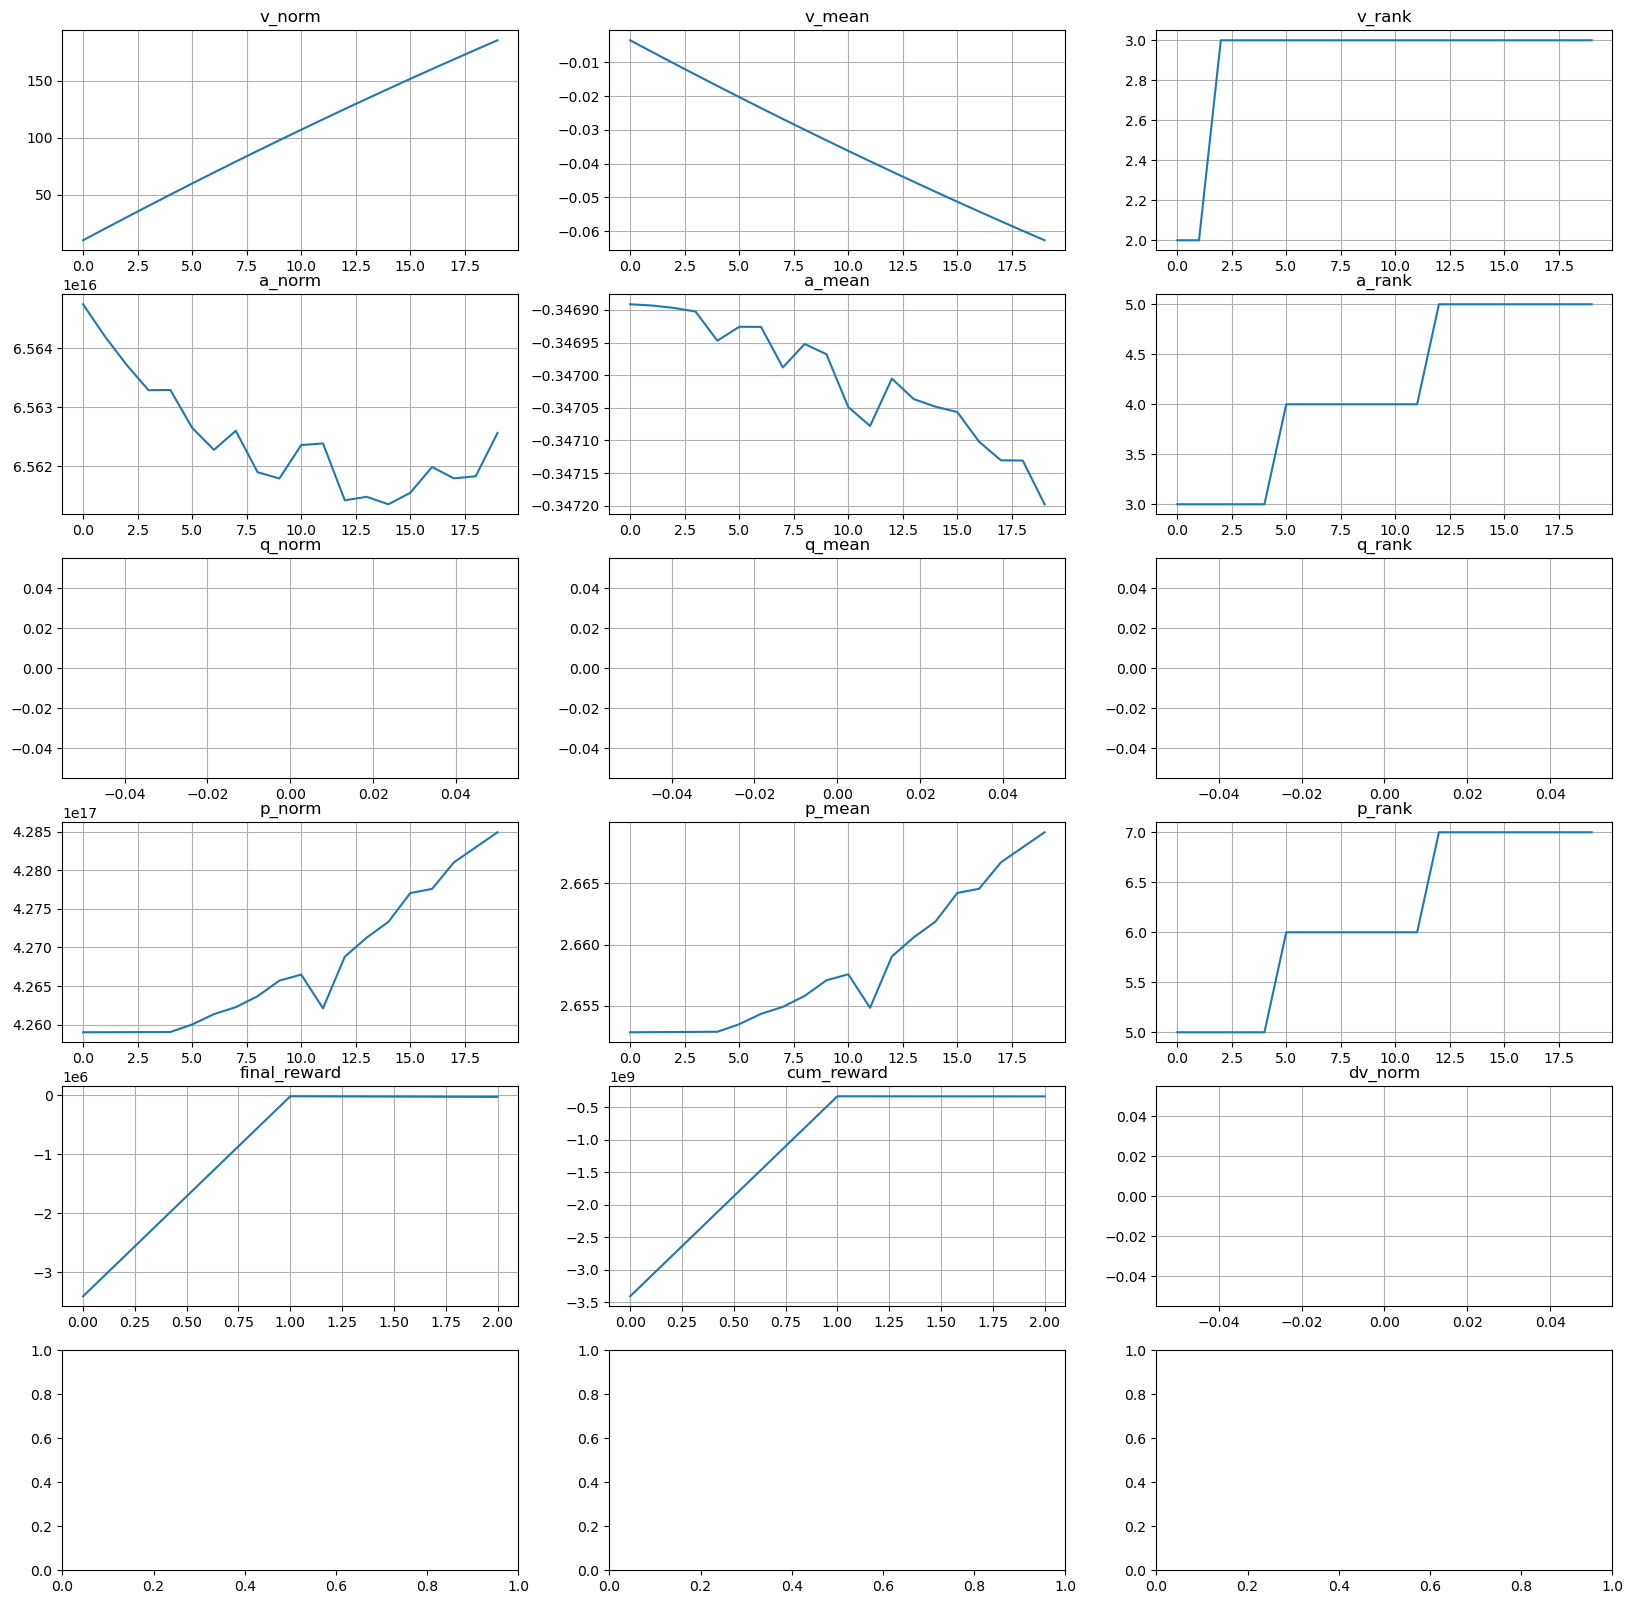

Memory:  0.0 0.0
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Policy Iteration 21/1000
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Number of value updates:  1
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
.....................................................
Computing Advantage Fcn
.....................................................
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
v_min: -0.19, v_mean: -0.07, v_max: -0.00
a_min: -1.01, a_mean: -0.35, a_max: -0.00
p_min: 2.01, p_mean: 2.67, p_max: 3.02
Rank of V-model:  tensor([1, 3, 3, 2, 1])
Rank of A-model:  tensor([1, 4, 5, 4, 3, 4, 3, 4, 3, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])
R

KeyboardInterrupt: 

In [13]:
resume= False
ttpi.train(resume=resume,n_iter_v=1, 
        callback=callback, callback_freq=10,
        verbose=False, file_name='HardMove')